# Task 2 — Yelp Polarity Sentiment Model Comparison

This notebook trains and evaluates a mean-embedding baseline, a multi-kernel CNN, and a bidirectional GRU using trainable embeddings.


## 2.1 Data Preprocessing — Setup

In [1]:
%pip -q install datasets scikit-learn seaborn psutil


In [2]:
import os
import re
import time
import random
import platform
import resource
import json
from pathlib import Path

BASE_DIR = Path(os.environ.get("TASK2_RUN_DIR", "/content/sample_data/TASK2_RUN_DIR")).resolve()
RUN_DIR = BASE_DIR / "all_models"
SRC_DIR = RUN_DIR / "src"
DATA_PROCESSED_DIR = RUN_DIR / "data_processed"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
OUTPUT_DIR = RUN_DIR / "outputs"
for folder in (RUN_DIR, SRC_DIR, DATA_PROCESSED_DIR, CHECKPOINT_DIR, OUTPUT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

RUN_LOG_PATH = RUN_DIR / "RUN_LOG.txt"
RUN_LOG_PATH.touch(exist_ok=True)

def write_run_log(message):
    message = str(message)
    with RUN_LOG_PATH.open("a", encoding="utf-8") as log_file:
        log_file.write(message + "\n")
        log_file.flush()
    print(message, flush=True)

write_run_log(f"\n===== Task 2 all-model run started: {time.strftime('%Y-%m-%d %H:%M:%S')} =====")
print("Run directory:", RUN_DIR)
print("Log path:", RUN_LOG_PATH)



===== Task 2 all-model run started: 2026-10-05 01:19:44 =====
Run directory: /content/sample_data/TASK2_RUN_DIR/all_models
Log path: /content/sample_data/TASK2_RUN_DIR/all_models/RUN_LOG.txt


In [3]:
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [5]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, average_precision_score,
    matthews_corrcoef, brier_score_loss, f1_score)
from scipy.stats import binom

In [6]:
SID4 = 9002
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# Improved settings for the final comparison run.
MAX_TRAIN = 20_000
MAX_TEST = 5_000
VAL_SIZE = 0.10
MAX_VOCAB = 30_000
MAX_LEN = 180
BATCH_SIZE = 128
EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

print({"SID4": SID4, "SEED": SEED, "SLICE": SLICE, "HP_ID": HP_ID,
       "CLS_A": CLS_A, "CLS_B": CLS_B})
USE_STEMMING = False


{'SID4': 9002, 'SEED': 9002, 'SLICE': 2, 'HP_ID': 2, 'CLS_A': 2, 'CLS_B': 3}


In [7]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything()
print("Device:", DEVICE)
print("Device name:", torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else platform.processor())
print("PyTorch:", torch.__version__)

Device: cuda
Device name: Tesla T4
PyTorch: 2.11.0+cu130


## 2.1.1 Analyse review length distribution, class distribution, and balance

In [8]:
dataset = load_dataset("fancyzhx/yelp_polarity")
train_raw = pd.DataFrame(dataset["train"])
test_raw = pd.DataFrame(dataset["test"])

print(dataset)
print("Train:", train_raw.shape, "Test:", test_raw.shape)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})
Train: (560000, 2) Test: (38000, 2)


In [9]:
print("\nMissing values:")
print(pd.concat({"train": train_raw.isna().sum(), "test": test_raw.isna().sum()}, axis=1))
print("\nClass counts:")
print(train_raw["label"].value_counts().sort_index())


Missing values:
       train  test
text       0     0
label      0     0

Class counts:
label
0    280000
1    280000
Name: count, dtype: int64


In [10]:
print("\nClass proportions:")
print(train_raw["label"].value_counts(normalize=True).sort_index().round(4))


Class proportions:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [11]:
lengths = train_raw["text"].astype(str).str.split().str.len()
print(lengths.describe(percentiles=[.5, .75, .9, .95, .99]).round(2))

count    560000.00
mean        133.03
std         122.61
min           1.00
50%          97.00
75%         174.00
90%         282.00
95%         372.00
99%         608.00
max        1052.00
Name: text, dtype: float64


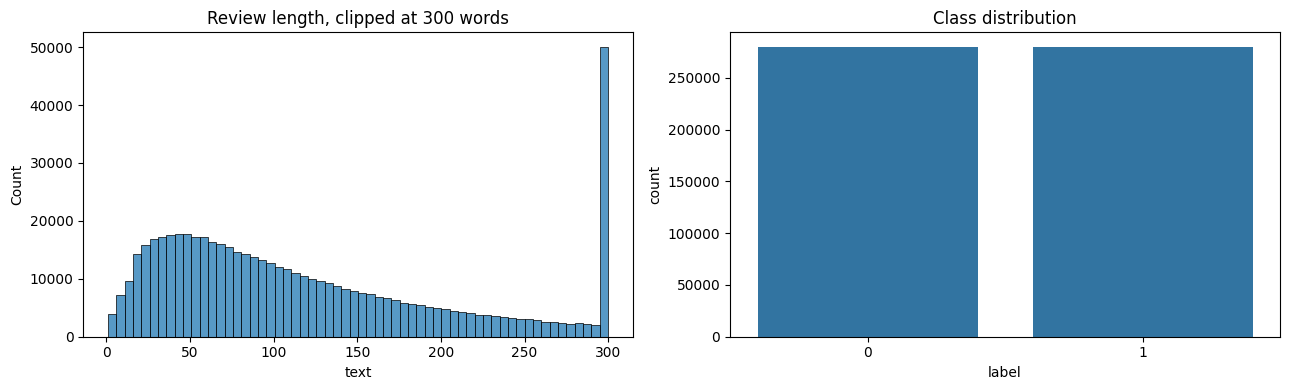

In [12]:
fig, ax= plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(lengths.clip(upper=300), bins=60, ax=ax[0])
ax[0].set_title("Review length, clipped at 300 words")
sns.countplot(data=train_raw, x="label", ax=ax[1])
ax[1].set_title("Class distribution")
plt.tight_layout()

## 2.1.2 Handle missing and malformed entries

Rows with missing text, non-numeric labels, non-binary labels, or empty processed text are removed.

In [13]:
STOPWORDS = {
    "a","an","and","are","as","at","be","but","by","for","from","has","have","he","her",
    "i","if","in","is","it","its","me","my","of","on","or","our","she","so","that","the",
    "their","there","they","this","to","was","we","were","what","when","which","who",
    "will","with","you","your"
    # not, never, and no are intentionally retained because they change polarity.
}

## 2.1.3 Lowercase, remove punctuation, stopwords, and stem

In [14]:
def light_stem(token):
    for suffix in ("ingly", "edly", "ing", "ed", "ies", "es", "s"):
        if len(token) > len(suffix) + 3 and token.endswith(suffix):
            return token[:-len(suffix)]
    return token

In [15]:
def tokenize(text):
    text = re.sub(r"[^a-z0-9\s' ]", " ", str(text).lower())
    words = re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?", text)
    words = [w for w in words if w not in STOPWORDS]
    return [light_stem(w) for w in words] if USE_STEMMING else words

print(tokenize("The food was AMAZING!!! I wouldn't order it again."))

['food', 'amazing', "wouldn't", 'order', 'again']


## 2.1.4 Clean, sample, and split the data

In [16]:
def clean_frame(frame):
    out = frame[["text", "label"]].copy()
    out["text"] = out["text"].fillna("").astype(str)
    out["label"] = pd.to_numeric(out["label"], errors="coerce")
    out = out.dropna(subset=["label"])
    out = out[out["label"].isin([0, 1])]
    out["tokens"] = out["text"].map(tokenize)
    return out[out["tokens"].map(len) > 0].reset_index(drop=True)

In [17]:
train_df = clean_frame(train_raw)
test_df = clean_frame(test_raw)

In [18]:
if MAX_TRAIN is not None:
    train_df, _ = train_test_split(train_df, train_size=MAX_TRAIN,
        stratify=train_df["label"], random_state=SEED)
if MAX_TEST is not None:
    test_df, _ = train_test_split(test_df, train_size=MAX_TEST,
        stratify=test_df["label"], random_state=SEED)

In [19]:
train_df, val_df = train_test_split(train_df.reset_index(drop=True), test_size=VAL_SIZE,
    stratify=train_df["label"], random_state=SEED)
train_df = train_df.reset_index(drop=True); val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [20]:
print("Rows:", len(train_df), "train |", len(val_df), "validation |", len(test_df), "test")

Rows: 18000 train | 2000 validation | 5000 test


In [21]:
print("Rows remaining after cleaning:", len(train_df), "train |", len(val_df), "validation |", len(test_df), "test")
print("Class balance after sampling and split:")
print(pd.DataFrame({"train": train_df["label"].value_counts(normalize=True),
                    "validation": val_df["label"].value_counts(normalize=True),
                    "test": test_df["label"].value_counts(normalize=True)}).sort_index().round(4))

Rows remaining after cleaning: 18000 train | 2000 validation | 5000 test
Class balance after sampling and split:
       train  validation  test
label                         
0        0.5         0.5   0.5
1        0.5         0.5   0.5


## 2.1.5 Tokenise and learn embeddings from scratch

In [22]:
PAD, UNK = "<pad>", "<unk>"
counts = Counter(t for row in train_df["tokens"] for t in row)
vocab_tokens = [PAD, UNK] + [t for t, _ in counts.most_common(MAX_VOCAB - 2)]
stoi = {t: i for i, t in enumerate(vocab_tokens)}
print("Vocabulary size:", len(stoi))
print("Most common:", counts.most_common(15))

Vocabulary size: 30000
Most common: [('n', 26126), ('not', 16335), ('had', 14438), ('food', 10605), ('place', 10363), ('good', 9722), ('out', 8691), ('all', 8609), ('like', 8459), ('just', 8313), ('get', 7842), ('very', 7655), ('one', 7577), ('here', 7365), ('time', 7083)]


In [23]:
def encode(tokens):
    ids = [stoi.get(t, stoi[UNK]) for t in tokens[:MAX_LEN]]
    return ids or [stoi[UNK]]

In [24]:
class ReviewDataset(Dataset):
    def __init__(self, frame):
        self.x = [encode(t) for t in frame["tokens"]]
        self.y = frame["label"].astype(int).to_numpy()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], int(self.y[i]), i

In [25]:
def collate_batch(batch):
    seqs, ys, ids = zip(*batch)
    batch_len = max(7, max(map(len, seqs)))
    x = torch.full((len(seqs), batch_len), stoi[PAD], dtype=torch.long)
    for r, seq in enumerate(seqs): x[r, :len(seq)] = torch.tensor(seq)
    return x, torch.tensor(ys, dtype=torch.float32), torch.tensor(ids)

In [26]:
def loader(frame, shuffle=False):
    return DataLoader(ReviewDataset(frame), batch_size=BATCH_SIZE, shuffle=shuffle,
        collate_fn=collate_batch, num_workers=0, pin_memory=DEVICE.type == "cuda")

train_loader = loader(train_df, True)
val_loader = loader(val_df)
test_loader = loader(test_df)

## 2.2 Model Training and Evaluation — Architecture justification

### Model lineup

- **Baseline:** learned embeddings with masked mean pooling and a linear classifier.
- **Experimental CNN:** learned embeddings with multiple convolution widths for local phrases.
- **Experimental BiGRU:** learned embeddings with bidirectional sequence context.
- All embeddings are randomly initialized and learned only from the training data.

## 2.2.1 Baseline model

In [27]:
class MeanEmbeddingBaseline(nn.Module):
    def __init__(self, vocab, dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab, dim, padding_idx=stoi[PAD])
        self.classifier = nn.Sequential(nn.Dropout(.20), nn.Linear(dim, 1))
    def forward(self, x):
        mask = (x != stoi[PAD]).unsqueeze(-1)
        h = self.embedding(x)
        pooled = (h * mask).sum(1) / mask.sum(1).clamp_min(1)
        return self.classifier(pooled).squeeze(1)

## 2.2.2 Experimental CNN model

In [28]:
class CNNTextClassifier(nn.Module):
    def __init__(self, vocab, dim=160, channels=128, kernels=(3, 5, 7)):
        super().__init__()
        self.embedding = nn.Embedding(vocab, dim, padding_idx=stoi[PAD])
        self.convs = nn.ModuleList([nn.Conv1d(dim, channels, k) for k in kernels])
        self.dropout = nn.Dropout(.35)
        self.classifier = nn.Linear(channels * len(kernels), 1)
    def forward(self, x):
        h = self.embedding(x).transpose(1, 2)
        pooled = [torch.relu(c(h)).amax(2) for c in self.convs]
        return self.classifier(self.dropout(torch.cat(pooled, 1))).squeeze(1)

## 2.2.3 Experimental BiGRU model

In [29]:
class BiGRUClassifier(nn.Module):
    def __init__(self, vocab, dim=160, hidden=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab, dim, padding_idx=stoi[PAD])
        self.gru = nn.GRU(dim, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(.35)
        self.classifier = nn.Linear(hidden * 2, 1)
    def forward(self, x):
        mask = (x != stoi[PAD]).unsqueeze(-1)
        h, _ = self.gru(self.embedding(x))
        pooled = (h * mask).sum(1) / mask.sum(1).clamp_min(1)
        return self.classifier(self.dropout(pooled)).squeeze(1)

## 2.2.4 Model factory and parameter counts

In [30]:
model_factories = {
    "baseline_mean_embedding": lambda: MeanEmbeddingBaseline(len(stoi)),
    "experimental_cnn": lambda: CNNTextClassifier(len(stoi)),
    "experimental_bigru": lambda: BiGRUClassifier(len(stoi)),
}
for name, make in model_factories.items():
    print(name, sum(p.numel() for p in make().parameters() if p.requires_grad), "parameters")

baseline_mean_embedding 3840129 parameters
experimental_cnn 5107969 parameters
experimental_bigru 5022977 parameters


## 2.2.5 Training utilities and exact CPU/GPU

In [31]:
def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [32]:
@torch.no_grad()
def predict(model, data_loader):
    model.eval(); ys, ps, ids = [], [], []
    for x, y, idx in data_loader:
        ps.extend(torch.sigmoid(model(x.to(DEVICE))).cpu().numpy())
        ys.extend(y.numpy()); ids.extend(idx.numpy())
    return np.asarray(ys).astype(int), np.asarray(ps), np.asarray(ids).astype(int)

In [33]:
def train_one(name, make):
    seed_everything()
    model = make().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.BCEWithLogitsLoss()
    history = []
    if DEVICE.type == "cuda": torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()
    for epoch in range(1, EPOCHS + 1):
        model.train(); total = 0; seen = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(x), y); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            total += loss.item() * len(y); seen += len(y)
        vy, vp, _ = predict(model, val_loader)
        history.append({"model": name, "epoch": epoch, "train_loss": total/seen,
            "val_macro_f1": f1_score(vy, vp >= .5, average="macro")})
        write_run_log(f"{name} | epoch {epoch}/{EPOCHS} | loss {total/seen:.4f} | "
              f"val macro-F1 {history[-1]['val_macro_f1']:.4f}")
    elapsed = time.perf_counter() - start
    vy, vp, _ = predict(model, val_loader)
    thresholds = np.linspace(.20, .80, 61)
    threshold = max(thresholds, key=lambda t: f1_score(vy, vp >= t, average="macro"))
    y, p, ids = predict(model, test_loader)
    peak = (torch.cuda.max_memory_allocated() / 2**20 if DEVICE.type == "cuda"
            else resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024)
    cpu_name = platform.processor()
    if not cpu_name:
        try:
            with open("/proc/cpuinfo", encoding="utf-8") as f:
                cpu_name = next((line.split(":", 1)[1].strip() for line in f
                    if line.lower().startswith("model name")), platform.machine())
        except OSError:
            cpu_name = platform.machine()
    resources = {"model": name, "parameters": parameter_count(model),
        "training_seconds": elapsed, "examples_per_second": len(train_df)*EPOCHS/elapsed,
        "peak_memory_mb": peak, "device": str(DEVICE),
        "device_name": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else cpu_name,
        "decision_threshold": threshold}
    return model, pd.DataFrame(history), y, p, ids, resources, threshold

## 2.2.6 Train all three models

Run this cell after the model and training utility cells. It records model parameters, training time, examples per second, peak memory, and exact hardware.

In [34]:
runs, histories, resource_rows = {}, [], []
for name, make in model_factories.items():
    model, hist, y, p, ids, res, threshold = train_one(name, make)
    runs[name] = {"model": model, "y": y, "p": p, "ids": ids, "threshold": threshold}
    histories.append(hist)
    resource_rows.append(res)

    torch.save({
        "model_name": name,
        "state_dict": model.state_dict(),
        "threshold": threshold,
        "seed": SEED,
    }, CHECKPOINT_DIR / f"{name}.pt")

    pd.DataFrame({
        "label": y,
        "prob_positive": p,
        "prediction": (p >= threshold).astype(int),
    }).to_csv(OUTPUT_DIR / f"predictions_{name}.csv", index=False)
    write_run_log(f"Saved checkpoint and predictions for {name}; threshold={threshold:.2f}")

history_df = pd.concat(histories, ignore_index=True)
resource_df = pd.DataFrame(resource_rows)
display(resource_df)
history_df.to_csv(OUTPUT_DIR / "training_history_all_models.csv", index=False)
resource_df.to_csv(RUN_DIR / "resources_report.csv", index=False)


baseline_mean_embedding | epoch 1/5 | loss 0.6555 | val macro-F1 0.7851
baseline_mean_embedding | epoch 2/5 | loss 0.5211 | val macro-F1 0.8465
baseline_mean_embedding | epoch 3/5 | loss 0.3884 | val macro-F1 0.8755
baseline_mean_embedding | epoch 4/5 | loss 0.3097 | val macro-F1 0.8915
baseline_mean_embedding | epoch 5/5 | loss 0.2609 | val macro-F1 0.9010
Saved checkpoint and predictions for baseline_mean_embedding; threshold=0.53
experimental_cnn | epoch 1/5 | loss 0.5075 | val macro-F1 0.8520
experimental_cnn | epoch 2/5 | loss 0.3011 | val macro-F1 0.8850
experimental_cnn | epoch 3/5 | loss 0.1977 | val macro-F1 0.8844
experimental_cnn | epoch 4/5 | loss 0.1372 | val macro-F1 0.8990
experimental_cnn | epoch 5/5 | loss 0.1075 | val macro-F1 0.9010
Saved checkpoint and predictions for experimental_cnn; threshold=0.56
experimental_bigru | epoch 1/5 | loss 0.4313 | val macro-F1 0.8695
experimental_bigru | epoch 2/5 | loss 0.2512 | val macro-F1 0.8935
experimental_bigru | epoch 3/5 | l

,model,parameters,training_seconds,examples_per_second,peak_memory_mb,device,device_name,decision_threshold
0,baseline_mean_embedding,3840129,6.346666,14180.673566,100.473145,cuda,Tesla T4,0.53
1,experimental_cnn,5107969,18.980147,4741.796693,236.123047,cuda,Tesla T4,0.56
2,experimental_bigru,5022977,16.025881,5615.915855,558.246582,cuda,Tesla T4,0.27


## 2.2.7 Training curves

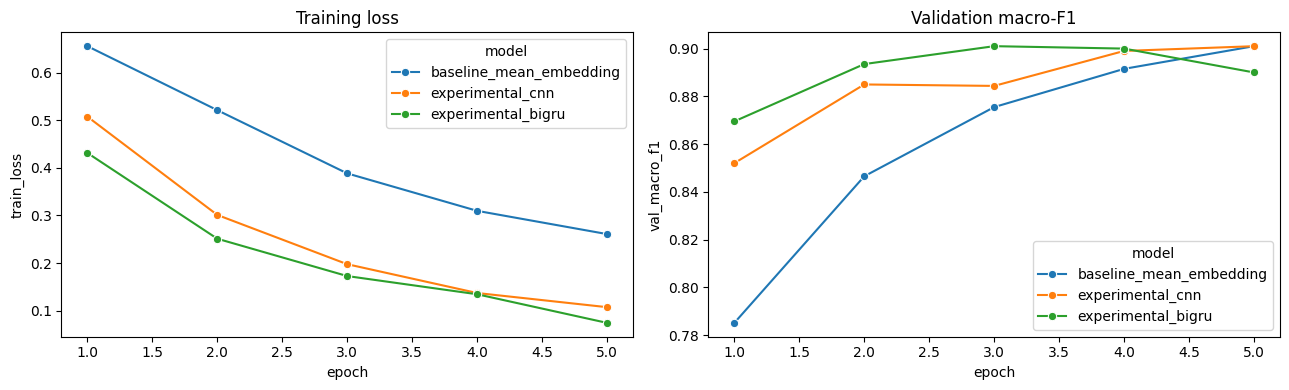

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=history_df, x="epoch", y="train_loss", hue="model", marker="o", ax=ax[0])
sns.lineplot(data=history_df, x="epoch", y="val_macro_f1", hue="model", marker="o", ax=ax[1])
ax[0].set_title("Training loss"); ax[1].set_title("Validation macro-F1")
plt.tight_layout()


## 2.2.8 Accuracy, precision, recall, F1, calibration, and confidence intervals

In [36]:
def ece(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1); value = 0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (p >= lo) & (p <= hi if hi == 1 else p < hi)
        if mask.any(): value += mask.mean() * abs(p[mask].mean() - y[mask].mean())
    return float(value)

In [37]:
def bootstrap_ci(y, pred, metric, n=1000):
    rng = np.random.default_rng(SEED); vals = []
    for _ in range(n):
        ix = rng.integers(0, len(y), len(y)); vals.append(metric(y[ix], pred[ix]))
    return np.percentile(vals, [2.5, 97.5])

In [38]:
def metrics(model_name, y, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    result = {
        "model": model_name,
        "decision_threshold": threshold,
        "accuracy": accuracy_score(y, predictions),
    }
    for average in ("macro", "micro", "weighted"):
        precision, recall, f1, _ = precision_recall_fscore_support(
            y, predictions, average=average, zero_division=0
        )
        result[f"precision_{average}"] = precision
        result[f"recall_{average}"] = recall
        result[f"f1_{average}"] = f1
    result.update({
        "roc_auc": roc_auc_score(y, probabilities),
        "pr_auc": average_precision_score(y, probabilities),
        "mcc": matthews_corrcoef(y, predictions),
        "brier_score": brier_score_loss(y, probabilities),
        "ece_10_bins": ece(y, probabilities),
    })
    result["accuracy_ci95"] = bootstrap_ci(y, predictions, accuracy_score)
    result["macro_f1_ci95"] = bootstrap_ci(
        y, predictions, lambda a, b: f1_score(a, b, average="macro", zero_division=0)
    )
    result["mcc_ci95"] = bootstrap_ci(y, predictions, matthews_corrcoef)
    return result


metric_df = pd.DataFrame([
    metrics(model_name, run["y"], run["p"], run["threshold"])
    for model_name, run in runs.items()
])
display(metric_df.round(4))
metric_df.to_csv(RUN_DIR / "metrics_report.csv", index=False)
resource_df.to_csv(RUN_DIR / "resources_report.csv", index=False)
write_run_log("Metrics summary:")
write_run_log(metric_df.to_string(index=False))


,model,decision_threshold,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted,roc_auc,pr_auc,mcc,brier_score,ece_10_bins,accuracy_ci95,macro_f1_ci95,mcc_ci95
0,baseline_mean_embedding,0.53,0.8914,0.8921,0.8914,0.8914,0.8914,0.8914,0.8914,0.8921,0.8914,0.8914,0.9574,0.9574,0.7835,0.0825,0.0530,"[0.8826, 0.8996]","[0.8825955848666895, 0.8995631919002871]","[0.7662326001709936, 0.7996787878955269]"
1,experimental_cnn,0.56,0.9054,0.9054,0.9054,0.9054,0.9054,0.9054,0.9054,0.9054,0.9054,0.9054,0.9660,0.9652,0.8108,0.0717,0.0301,"[0.8974, 0.913605]","[0.8973959467249489, 0.913604914024959]","[0.7949517155097238, 0.8273029092921104]"
2,experimental_bigru,0.27,0.8880,0.8883,0.8880,0.8880,0.8880,0.8880,0.8880,0.8883,0.8880,0.8880,0.9601,0.9608,0.7763,0.0904,0.0711,"[0.878995, 0.8966]","[0.8787996897272057, 0.8964601262471876]","[0.7583571875496498, 0.7934886316314119]"


Metrics summary:
                  model  decision_threshold  accuracy  precision_macro  recall_macro  f1_macro  precision_micro  recall_micro  f1_micro  precision_weighted  recall_weighted  f1_weighted  roc_auc   pr_auc      mcc  brier_score  ece_10_bins      accuracy_ci95                            macro_f1_ci95                                 mcc_ci95
baseline_mean_embedding                0.53    0.8914         0.892092        0.8914  0.891352           0.8914        0.8914    0.8914            0.892092           0.8914     0.891352 0.957359 0.957428 0.783491     0.082544     0.052954   [0.8826, 0.8996] [0.8825955848666895, 0.8995631919002871] [0.7662326001709936, 0.7996787878955269]
       experimental_cnn                0.56    0.9054         0.905405        0.9054  0.905400           0.9054        0.9054    0.9054            0.905405           0.9054     0.905400 0.965983 0.965196 0.810805     0.071710     0.030130 [0.8974, 0.913605]  [0.8973959467249489, 0.913604914024959] [0.7

## 2.2.9 Confusion matrices

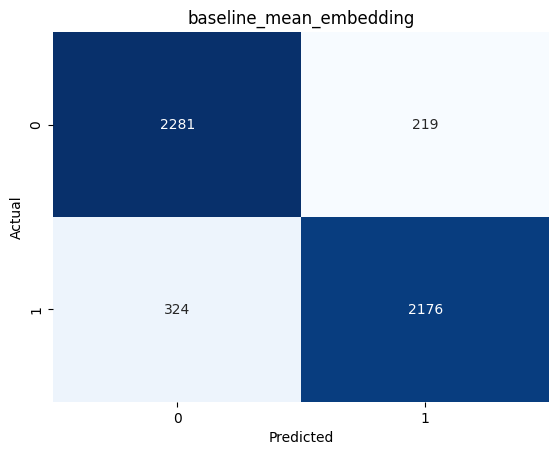

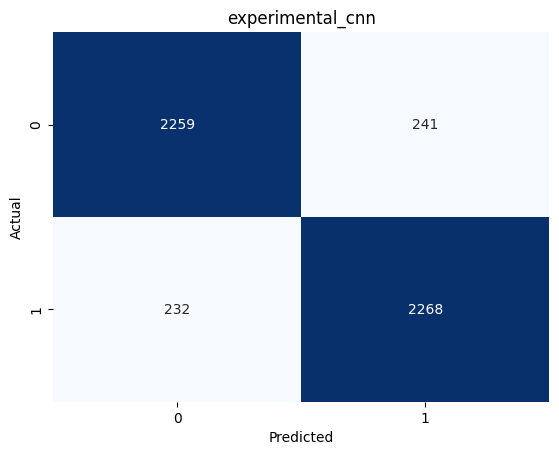

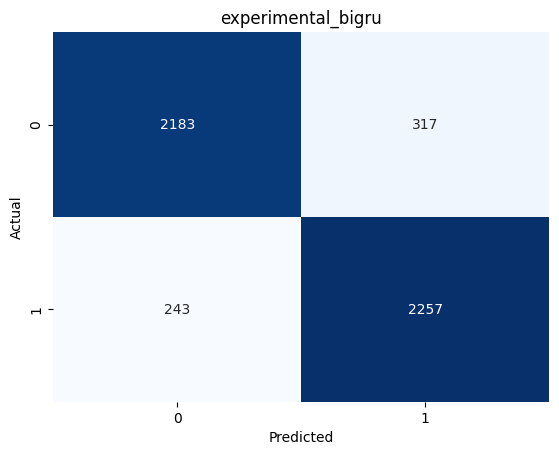

In [39]:
for name, run in runs.items():
    cm = confusion_matrix(run["y"], run["p"] >= run["threshold"])
    pd.DataFrame(cm, index=["actual_0", "actual_1"],
                 columns=["predicted_0", "predicted_1"]).to_csv(
        OUTPUT_DIR / f"confusion_matrix_{name}.csv")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## 2.2.10 Paired McNemar tests

In [40]:
def mcnemar_exact(y, p_base, p_exp, t_base=.5, t_exp=.5):
    a, b = p_base >= t_base, p_exp >= t_exp
    b01 = int(np.sum((a == y) & (b != y)))
    b10 = int(np.sum((a != y) & (b == y)))
    n = b01 + b10
    p = 1.0 if n == 0 else min(1.0, 2 * binom.cdf(min(b01, b10), n, .5))
    return b01, b10, p

In [41]:
base = runs["baseline_mean_embedding"]
rows = []
for name, run in runs.items():
    if name != "baseline_mean_embedding":
        a, b, p = mcnemar_exact(base["y"], base["p"], run["p"],
                                  base["threshold"], run["threshold"])
        rows.append({"comparison": f"baseline vs {name}",
            "baseline_correct_exp_wrong": a,
            "baseline_wrong_exp_correct": b, "exact_p_value": p})
mcnemar_df = pd.DataFrame(rows)
display(mcnemar_df)
mcnemar_df.to_csv(OUTPUT_DIR / "mcnemar_results.csv", index=False)
write_run_log("McNemar results:\n" + mcnemar_df.to_string(index=False))

,comparison,baseline_correct_exp_wrong,baseline_wrong_exp_correct,exact_p_value
0,baseline vs experimental_cnn,168,238,0.000599
1,baseline vs experimental_bigru,275,258,0.488322


McNemar results:
                    comparison  baseline_correct_exp_wrong  baseline_wrong_exp_correct  exact_p_value
  baseline vs experimental_cnn                         168                         238       0.000599
baseline vs experimental_bigru                         275                         258       0.488322


## 2.2.11 Macro-F1 and error rate per robustness slice

In [42]:
slice_frame = test_df.copy()
slice_frame["word_count"] = slice_frame["tokens"].map(len)
slice_frame["length_slice"] = pd.cut(slice_frame["word_count"], [-1, 40, 100, np.inf],
    labels=["short", "medium", "long"])
slice_frame["negation_slice"] = slice_frame["text"].str.lower().str.contains(
    r"\b(not|never|no|n't)\b", regex=True)
slice_frame["punctuation_slice"] = np.where(
    slice_frame["text"].str.count(r"[!?]") >= 3, "high_punctuation", "low_punctuation")

/tmp/ipykernel_2668/2957509712.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  slice_frame["negation_slice"] = slice_frame["text"].str.lower().str.contains(


In [43]:
def slice_results_for(name, run, frame, column):
    rows = []
    for value in frame[column].dropna().unique():
        mask = frame[column].to_numpy() == value
        pred = (run["p"][mask] >= run["threshold"]).astype(int)
        rows.append({"model": name, "slice_type": column, "slice": str(value),
            "n": int(mask.sum()), "macro_f1": f1_score(run["y"][mask], pred,
            average="macro", zero_division=0), "error_rate": 1-accuracy_score(run["y"][mask], pred)})
    return rows

In [44]:
slice_rows = []
for name, run in runs.items():
    for col in ("length_slice", "negation_slice", "punctuation_slice"):
        slice_rows += slice_results_for(name, run, slice_frame, col)
slice_df = pd.DataFrame(slice_rows)
display(slice_df)
slice_df.to_csv(OUTPUT_DIR / "robustness_slices_all_models.csv", index=False)
write_run_log("Robustness slices:\n" + slice_df.to_string(index=False))

,model,slice_type,slice,n,macro_f1,error_rate
0,baseline_mean_embedding,length_slice,long,1457,0.896761,0.098833
1,baseline_mean_embedding,length_slice,short,1622,0.884447,0.112207
2,baseline_mean_embedding,length_slice,medium,1921,0.886842,0.112962
3,baseline_mean_embedding,negation_slice,True,2956,0.876490,0.112314
4,baseline_mean_embedding,negation_slice,False,2044,0.878911,0.103229
5,baseline_mean_embedding,punctuation_slice,low_punctuation,3896,0.882587,0.117300
6,baseline_mean_embedding,punctuation_slice,high_punctuation,1104,0.922085,0.077899
7,experimental_cnn,length_slice,long,1457,0.904834,0.091970
8,experimental_cnn,length_slice,short,1622,0.899987,0.096794
9,experimental_cnn,length_slice,medium,1921,0.905252,0.094742


Robustness slices:
                  model        slice_type            slice    n  macro_f1  error_rate
baseline_mean_embedding      length_slice             long 1457  0.896761    0.098833
baseline_mean_embedding      length_slice            short 1622  0.884447    0.112207
baseline_mean_embedding      length_slice           medium 1921  0.886842    0.112962
baseline_mean_embedding    negation_slice             True 2956  0.876490    0.112314
baseline_mean_embedding    negation_slice            False 2044  0.878911    0.103229
baseline_mean_embedding punctuation_slice  low_punctuation 3896  0.882587    0.117300
baseline_mean_embedding punctuation_slice high_punctuation 1104  0.922085    0.077899
       experimental_cnn      length_slice             long 1457  0.904834    0.091970
       experimental_cnn      length_slice            short 1622  0.899987    0.096794
       experimental_cnn      length_slice           medium 1921  0.905252    0.094742
       experimental_cnn    negation

## 2.2.12 Manual review of 20 model errors

Read the 20 selected rows and fill in manual_error_type and testable_fix. The automatic bucket is only a starting point; the final classification must be based on human review.

In [45]:
best_name = metric_df.sort_values("f1_macro", ascending=False).iloc[0]["model"]
best = runs[best_name]
review = test_df.iloc[best["ids"]].copy()
review["prob_positive"] = best["p"]; review["prediction"] = (best["p"] >= best["threshold"]).astype(int)
review["correct"] = review["prediction"].to_numpy() == review["label"].to_numpy()
review["confidence"] = np.abs(review["prob_positive"] - best["threshold"])
review["length_slice"] = pd.cut(review["tokens"].map(len), [-1,40,100,np.inf],
    labels=["short","medium","long"])
review["has_negation"] = review["text"].str.lower().str.contains(r"\b(not|never|no|n't)\b", regex=True)

/tmp/ipykernel_2668/2890817078.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  review["has_negation"] = review["text"].str.lower().str.contains(r"\b(not|never|no|n't)\b", regex=True)


In [46]:
# Select four non-overlapping groups of five errors.
used = set()
def take_unique(pool, n=5):
    global used
    pool = pool.loc[~pool.index.isin(used)]
    chosen = pool.head(n)
    used.update(chosen.index.tolist())
    return chosen

fp = take_unique(review[(review.label==0) & (review.prediction==1)]
                 .sort_values("confidence", ascending=False))
fn = take_unique(review[(review.label==1) & (review.prediction==0)]
                 .sort_values("confidence", ascending=False))
near_pool = review[~review.correct].sort_values("confidence")
near = take_unique(near_pool)
slice_pool = review[~review.correct &
                    (review.has_negation | (review.length_slice == "long"))]
slc = take_unique(slice_pool.sort_values("confidence", ascending=False))
if len(slc) < 5:
    fallback = take_unique(review[~review.correct].sort_values("confidence", ascending=False),
                           5 - len(slc))
    slc = pd.concat([slc, fallback])
assert len(fp) == len(fn) == len(near) == len(slc) == 5
assert len(used) == 20, "The final manual review must contain 20 unique rows."

In [47]:
def review_rows(frame, bucket):
    x = frame.copy(); x["review_bucket"] = bucket
    x["manual_error_type"] = ""; x["testable_fix"] = ""
    return x[["review_bucket","text","label","prob_positive","prediction",
              "length_slice","has_negation","manual_error_type","testable_fix"]]

In [48]:
error_review = pd.concat([review_rows(fp, "confident_false_positive"),
    review_rows(fn, "confident_false_negative"), review_rows(near, "near_threshold"),
    review_rows(slc, "slice_specific")], ignore_index=True)
assert len(error_review) == 20
write_run_log(f"Rows selected: {len(error_review)} | unique source rows: {len(used)} | model reviewed: {best_name}")
display(error_review)
error_review.to_csv(OUTPUT_DIR / "manual_error_review_all_models.csv", index=False)
write_run_log("Saved manual_error_review_all_models.csv. Complete the two manual columns.")

Rows selected: 20 | unique source rows: 20 | model reviewed: experimental_cnn


,review_bucket,text,label,prob_positive,prediction,length_slice,has_negation,manual_error_type,testable_fix
0,confident_false_positive,of all the buffets I had in Vegas this was my ...,0,0.999901,1,short,False,,
1,confident_false_positive,Dr.Adams is great! Rest of office parley run. ...,0,0.999758,1,short,False,,
2,confident_false_positive,Good location and friendly staff. But need add...,0,0.999704,1,short,False,,
3,confident_false_positive,"By far, the least impressive Cirque du Soleil ...",0,0.999635,1,short,True,,
4,confident_false_positive,"Attended the @SpaFitFinder launch party, with ...",0,0.999434,1,medium,True,,
5,confident_false_negative,"Great gym, but if you ever try to cancel your ...",1,0.000982,0,short,False,,
6,confident_false_negative,"I had dinner here last weekend, and decided to...",1,0.001123,0,medium,True,,
7,confident_false_negative,For all the people who sit down and don't get ...,1,0.002093,0,short,False,,
8,confident_false_negative,So instead of going to Gibson Automotive to ge...,1,0.002269,0,long,True,,
9,confident_false_negative,Outstanding food quality and customer service ...,1,0.002759,0,short,False,,


Saved manual_error_review_all_models.csv. Complete the two manual columns.


## 2.3 Comparative Analysis and Observations

In [49]:
final_comparison = metric_df[["model","accuracy","f1_macro","f1_micro","f1_weighted",
    "roc_auc","pr_auc","mcc","brier_score","ece_10_bins"]].merge(resource_df, on="model")
display(final_comparison.sort_values("f1_macro", ascending=False).round(4))


,model,accuracy,f1_macro,f1_micro,f1_weighted,roc_auc,pr_auc,mcc,brier_score,ece_10_bins,parameters,training_seconds,examples_per_second,peak_memory_mb,device,device_name,decision_threshold
1,experimental_cnn,0.9054,0.9054,0.9054,0.9054,0.9660,0.9652,0.8108,0.0717,0.0301,5107969,18.9801,4741.7967,236.1230,cuda,Tesla T4,0.56
0,baseline_mean_embedding,0.8914,0.8914,0.8914,0.8914,0.9574,0.9574,0.7835,0.0825,0.0530,3840129,6.3467,14180.6736,100.4731,cuda,Tesla T4,0.53
2,experimental_bigru,0.8880,0.8880,0.8880,0.8880,0.9601,0.9608,0.7763,0.0904,0.0711,5022977,16.0259,5615.9159,558.2466,cuda,Tesla T4,0.27


Use the tables above to write the discussion in `METRICS.md` after the run.

- Compare macro-F1, MCC, ROC-AUC, PR-AUC, calibration, and 95% bootstrap intervals.
- Explain whether the CNN helps local phrase patterns and whether the BiGRU helps sequence context.
- Identify the weakest length, negation, and punctuation slices.
- Compare accuracy, training time, examples/sec, parameter count, and peak memory.
- Treat this as a deliberately small baseline: sample cap, two epochs, stemming, stopword removal, and a fixed 0.5 threshold are limitations.
- Propose testable improvements: preserve more context, tune the threshold on validation data, use subwords, train longer, increase the sample, and compare against a second dataset.

Important preprocessing decision: `not`, `never`, and `no` are retained because removing negation can reverse sentiment meaning.

In [50]:
# Save final member-level reports.
metric_df.to_csv(RUN_DIR / "metrics_report.csv", index=False)

results_text = "# Task 2 Results\n\n"
results_text += "Three from-scratch Yelp Polarity models were trained: a mean-embedding baseline, a CNN, and a BiGRU.\n\n"
results_text += "## Model comparison\n\n"
results_text += metric_df[["model", "accuracy", "f1_macro", "roc_auc", "pr_auc", "mcc", "brier_score", "ece_10_bins"]].round(4).to_string(index=False)
results_text += "\n\nComplete metrics are stored in `metrics_report.csv`. Checkpoints are stored in `checkpoints/`."
(RUN_DIR / "results.md").write_text(results_text + "\n", encoding="utf-8")

failure_text = "# Failure Analysis\n\n"
failure_text += f"The best model was `{best_name}`. The exported file `outputs/manual_error_review_{best_name}.csv` contains 20 unique rows for review.\n\n"
failure_text += "Review five confident false positives, five confident false negatives, five near-threshold errors, and five slice-specific failures. Complete the `manual_error_type` and `testable_fix` columns before submission."
(RUN_DIR / "failure_analysis.md").write_text(failure_text + "\n", encoding="utf-8")

write_run_log(f"Results report: {RUN_DIR / 'results.md'}")
write_run_log(f"Failure analysis: {RUN_DIR / 'failure_analysis.md'}")
write_run_log(f"Final log path: {RUN_LOG_PATH.resolve()}")
write_run_log(f"Final log size: {RUN_LOG_PATH.stat().st_size} bytes")


Results report: /content/sample_data/TASK2_RUN_DIR/all_models/results.md
Failure analysis: /content/sample_data/TASK2_RUN_DIR/all_models/failure_analysis.md
Final log path: /content/sample_data/TASK2_RUN_DIR/all_models/RUN_LOG.txt
Final log size: 10722 bytes


In [51]:
write_run_log(f"Final log path: {RUN_LOG_PATH.resolve()}")
write_run_log(f"Final log size: {RUN_LOG_PATH.stat().st_size} bytes")
print("The log was saved automatically. In Colab, download it with the next cell.")

Final log path: /content/sample_data/TASK2_RUN_DIR/all_models/RUN_LOG.txt
Final log size: 10824 bytes
The log was saved automatically. In Colab, download it with the next cell.


In [52]:
try:
    from google.colab import files
    files.download(str(RUN_LOG_PATH))
except ImportError:
    print("Not running in Colab. Open or download this file from:", RUN_LOG_PATH.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>